---
title: "PORTFORLIO 7"
author: "Cherie Julian"
format: 
  html:
      page-layout: full
      grid:
          body-width: 1200px
      embed-resources: true   
      toc: true
      toc-expand: 1
      toc-depth: 4
echo: false
jupyter: python3
---


::: {.content-hidden}
### Import necessary libraries & load data
:::

In [11]:
from functools import reduce
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import itables


## Objective

This data analysis project will analyse Perth Metropolitan's crash data to investigate how **time of day** and **speed limits** influences the likelihood of a **crash and severity**:

The analysis aims to address the following questions:

- Does a time of day affect the no. of crashes? i.e. peak commute traffic? When everyone is going home after a long day, and are likely to have less patience and focus.
- Does weekdays have more crashes compared to the weekend?
- Are crashes likely to occur in higher speed limit areas?
- Does the time of day or speed limits influence crash severity?

## 1. The Data

The crash data obtained from data.wa.gov.au (sourced from Main Roads) covers a 5-year period (2019-2023) and contains 126,869 crash incidents for all of WA (i.e. Perth Metropolitan + Greater Region).

Unfortunately, the crash data did not include the maximum road speed limits, a variable required to conduct this analysis.   

Speed limit information was therefore extracted from a second dataset (speed_limits.csv), also obtained from Main Roads.

In [12]:
crash_df = pd.read_csv("crash_data.csv")
speed_df = pd.read_csv("speed_limits.csv")

### 1.1 Initial Data Exploration - Speed Limits

In [13]:
itables.show(speed_df.head(100))

Loading ITables v2.7.3 from the internet... (need help?)


### 1.2 Initial Data Exploration - Crash Data

In [14]:
itables.show(crash_df.head(100))

Loading ITables v2.7.3 from the internet... (need help?)


### 1.3 Joining Datasets - Speed limits & Crash Data

Prior to joining the datasets, initial data exploration of the speed limit dataset revealed that the minimum and maximum speed limits were expressed as a string value.   

The below code was used to extract the maximum speed limit from this string into a new column, 'max_speed':

In [15]:
#| echo: true

def get_max_speed(text):
        speeds = list(map(lambda x: int(x), re.findall(r'\d+', str(text))))
        return max(speeds) if speeds else np.nan

speed_df['max_speed'] = list(map(get_max_speed, speed_df['SPEED_LIMIT']))



 Upon further inspection of the speed limit data, duplicate data exists as some roads have differrent types of carriageways (single, left or right) across different sections. These duplicates were deleted where all three values in 'ROAD', 'COMMON_USAGE_NAME', and 'max_speed' matched.

 Additionally, duplicates also arose as speed limits varied at different sections of the same road.  In such cases, only the maximum speed was retained where 'ROAD' and 'COMMON_USAGE_NAME' matched. 
 
 If duplicates were not removed, they could cause a data explosion on merging with the crash dataset.  

In [16]:
rows_before = len(speed_df)

In [17]:
seen = set()

def unique_filter(row):
    key = (row['ROAD'], row['COMMON_USAGE_NAME'], row['max_speed'])
    if key in seen:
        return False
    seen.add(key)
    return True

speed_df = speed_df[speed_df.apply(unique_filter, axis=1)]

In [18]:

data = speed_df.to_dict(orient='records')

def reducer(acc, row):
    key = (row['ROAD'], row['COMMON_USAGE_NAME'])
    
    if key not in acc:
        acc[key] = row
    else:
       
        if row['max_speed'] > acc[key]['max_speed']:
            acc[key] = row
            
    return acc

reduced_dict = reduce(reducer, data, {})

speed_df = pd.DataFrame(reduced_dict.values())

In [19]:
rows_after = len(speed_df)
print('No. of rows before duplicates deleted: ', rows_before)
print('No. of rows after duplicates deleted: ', rows_after)
print('No. of duplicates deleted: ', rows_before - rows_after)


No. of rows before duplicates deleted:  69507
No. of rows after duplicates deleted:  60695
No. of duplicates deleted:  8812


In [20]:
itables.show(speed_df.head(100))

Loading ITables v2.7.3 from the internet... (need help?)


After extracting the maximum speed limits and removing duplicates, the following columns from the speed data were merged into the crash dataset:

- RA_NAME: Refers to region locations (e.g. Metropolitan, South West, Wheatbelt)
- max_speed: Maximum road speed limit

The join will based on satisfying ALL the following conditions between the crash data and speed limit data:

- Road ID (ROAD_NO and ROAD)
- Common road name (COMMON_ROAD_NAME and COMMON_USAGE_NAME)

In [21]:
#A count was done before the join so that a check for data explosion can be done.
original_rows = len(crash_df)

In [ ]:
RUN_CODE=False #change to True for code to run

if RUN_CODE:    
    crash_df = crash_df.merge(
        speed_df[['ROAD', 'COMMON_USAGE_NAME', 'RA_NAME', 'max_speed']],
        left_on=['ROAD_NO', 'COMMON_ROAD_NAME'],
        right_on=['ROAD', 'COMMON_USAGE_NAME'],
        how='left'
    ).drop(columns=['ROAD', 'COMMON_USAGE_NAME'])


In [ ]:
# No need to run above code to join and save dataset as this has already been done and a copy provided.
#crash_df.to_csv('crash_data_joined.csv') 

The no. of rows before and after the join was checked to ensure no data explosion has occured:

In [24]:
joined_crash_df = pd.read_csv('crash_data_joined.csv')

new_rows = len(joined_crash_df)

print("Original rows:", original_rows)
print("New rows:", new_rows)

if original_rows == new_rows:
    print("No data explosion — row count unchanged")
else:
    print("Data explosion detected — row count changed")

Original rows: 126869
New rows: 126869
No data explosion — row count unchanged


## 2. Data Pre-processing: Crash Data

In [25]:
df = pd.read_csv('crash_data_joined.csv')

itables.show(df.head(100))

Loading ITables v2.7.3 from the internet... (need help?)


### 2.1 Handling Missing Values
Missing values were checked for Crash Date, Crash Time, Region and Max Speed as these variables are directly related to the analysis:


In [ ]:
missing_before = len(df)

print("Missing CRASH_DATE:", df['CRASH_DATE'].isna().sum())
print("Missing CRASH_TIME:", df['CRASH_TIME'].isna().sum())
print("Total no. of crash incidents:", missing_before)

Missing CRASH_DATE: 0
Missing CRASH_TIME: 109
Total no. of crash incidents: 126869


#### 2.1.1 Missing Data Visualisation

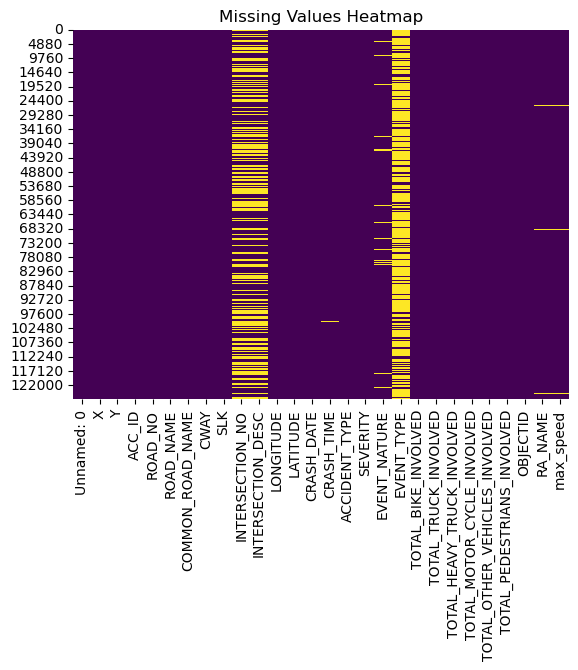

In [27]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

#### 2.1.2 Missing Values Deleted
Rows with the relevant missing data were determined to be minor (i.e. < 1% of the total dataset).  The missing data was subsequently deleted without affecting data quality.

In [ ]:
df = df.dropna(subset=['CRASH_TIME'])
percentage_deleted = (missing_before - len(df)) / missing_before * 100

print("Missing CRASH_TIME after deletion:", df['CRASH_DATE'].isna().sum())
print("Missing CRASH_TIME after deletion:", df['CRASH_TIME'].isna().sum())
print("Total no. of crash incidents after missing value handling:", len(df))
print("Total rows deleted:", missing_before - len(df))
print(f"Percentage of rows deleted: {percentage_deleted:.4f}%")


Missing CRASH_TIME after deletion: 0
Missing CRASH_TIME after deletion: 0
Total no. of crash incidents after missing value handling: 126760
Total rows deleted: 109
Percentage of rows deleted: 0.0859%


### 2.2 Data Validation

#### 2.2.1 Duplicates
A check for duplicates showed, none.

In [29]:
print("No. of duplicated rows:", df.index.duplicated().sum())

No. of duplicated rows: 0


#### 2.2.2 Handling Outliers & Validating Range
In Western Australia, the maximum speed limit is 110km/h. The below code was used to validate speed limits.  

In [31]:
#| echo: true
df = df[(df['max_speed'] >= 0) & (df['max_speed'] <= 110)]

### 2.3 Merge Sort
Merge sort was used to order roads by their unique identifier (ROAD_NO).

In [32]:

def merge_sort(arr, key):
    if len(arr) > 1:
        mid = len(arr) // 2
        left_half = arr[:mid]
        right_half = arr[mid:]

        merge_sort(left_half, key)
        merge_sort(right_half, key)

        i = j = k = 0

        while i < len(left_half) and j < len(right_half):
            if left_half[i][key] < right_half[j][key]:
                arr[k] = left_half[i]
                i += 1
            else:
                arr[k] = right_half[j]
                j += 1
            k += 1

        while i < len(left_half):
            arr[k] = left_half[i]
            i += 1
            k += 1

        while j < len(right_half):
            arr[k] = right_half[j]
            j += 1
            k += 1

    return arr


data = df.to_dict(orient='records')
sorted_data = merge_sort(data, 'ROAD_NO')
df = pd.DataFrame(sorted_data)


In [33]:
itables.show(df.head())

Loading ITables v2.7.3 from the internet... (need help?)


## 3. Data Transformation

### 3.1 Weekday vs Weekend - map() and lambda
To enable analysis of crash incidents occurring on weekdays versus weekends, a new categorical variable ('day_type') was created from ‘CRASH_DATE’ to distinguish between the two:

In [34]:
#| echo: true

df['CRASH_DATE'] = pd.to_datetime(df['CRASH_DATE'],dayfirst=True)

df['day_type'] = df['CRASH_DATE'].dt.weekday.map(
    lambda x: 'Weekend' if x >= 5 else 'Weekday')

### 3.2 Time of Day Classificaton - apply() and lambda
New categorical labels were created from ‘CRASH_TIME’ to enable deeper analysis of the times of day (e.g. offpeak, peak) when crash incidents are most likely to occur:

In [35]:
#| echo: true
df['time_of_day'] = df['CRASH_TIME'].apply(lambda x:
    'Morning Peak' if 600 <= x <= 959 else
    'Day Off-Peak' if 1000 <= x <= 1459 else
    'Afternoon Peak' if 1500 <= x <= 1830 else
    'Evening Off-Peak' if 1831 <= x <= 2200 else
    'Night Peak'  
)

### 3.3 Filter Data: Metropolitan Perth - filter() and lambda
As this analysis focusses on the Perth Metropolitan region only, the data was therefore, filtered to "Metropolitan" region only.

In [ ]:
#| echo: true

metro_df = list(filter(lambda x: x["RA_NAME"] == "Metropolitan", df.to_dict(orient="records")))

metro_df = pd.DataFrame(metro_df)

print ("No. fo rows BEFORE filtering:", len(df))
print ("No. fo rows AFTER filtering:", len(metro_df))
metro_df

No. fo rows BEFORE filtering: 125765
No. fo rows AFTER filtering: 105830


,Unnamed: 0,X,Y,ACC_ID,ROAD_NO,ROAD_NAME,COMMON_ROAD_NAME,CWAY,SLK,INTERSECTION_NO,...,TOTAL_TRUCK_INVOLVED,TOTAL_HEAVY_TRUCK_INVOLVED,TOTAL_MOTOR_CYCLE_INVOLVED,TOTAL_OTHER_VEHICLES_INVOLVED,TOTAL_PEDESTRIANS_INVOLVED,OBJECTID,RA_NAME,max_speed,day_type,time_of_day
0,126073,115.916098,-32.115467,11031971,1010001,Nicholson Rd,Nicholson Rd,L,0.00,36171.0,...,0,0,0,1,0,126074,Metropolitan,70.0,Weekday,Afternoon Peak
1,125985,115.922632,-32.179993,11024253,1010001,Nicholson Rd,Nicholson Rd,S,7.56,36178.0,...,0,0,0,1,0,125986,Metropolitan,70.0,Weekday,Morning Peak
2,125521,115.925276,-32.130691,11030996,1010001,Nicholson Rd,Nicholson Rd,L,2.05,201843.0,...,0,0,0,1,0,125522,Metropolitan,70.0,Weekend,Afternoon Peak
3,125113,115.922330,-32.162592,11022508,1010001,Nicholson Rd,Nicholson Rd,S,5.63,NaN,...,0,0,0,2,0,125114,Metropolitan,70.0,Weekday,Day Off-Peak
4,124923,115.916098,-32.115467,11029606,1010001,Nicholson Rd,Nicholson Rd,L,0.00,36171.0,...,0,0,0,2,0,124924,Metropolitan,70.0,Weekday,Afternoon Peak
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105825,14918,116.479645,-31.570219,10007438,M026,Toodyay Rd,Toodyay Rd,S,38.71,7100.0,...,0,0,0,1,0,14919,Metropolitan,100.0,Weekday,Night Peak
105826,11463,116.476030,-31.558150,9968371,M026,Toodyay Rd,Toodyay Rd,S,40.13,NaN,...,0,0,0,1,0,11464,Metropolitan,100.0,Weekday,Day Off-Peak
105827,10948,116.276651,-31.727517,9935751,M026,Toodyay Rd,Toodyay Rd,S,9.26,4000.0,...,0,0,0,2,0,10949,Metropolitan,100.0,Weekday,Afternoon Peak
105828,8964,116.448195,-31.605790,9942398,M026,Toodyay Rd,Toodyay Rd,S,32.32,NaN,...,0,0,0,1,0,8965,Metropolitan,100.0,Weekday,Evening Off-Peak


### 3.3 Aggregate Data - reduce() and lambda

#### 3.3.1 Crash incidents by time of day

In [37]:
#| echo: true
data = metro_df.to_dict(orient='records')

time_counts = reduce(lambda acc, row: {**acc,
        row['time_of_day']: acc.get(row['time_of_day'], 0) + 1},data,{})


Based on the crash data, the afternoon peak period has the highest frequency of crashes, followed by the day off-peak and the morning peak periods.

In [38]:
time_counts_df = pd.DataFrame(
    list(time_counts.items()),
    columns=['time_of_day', 'crash_count']
)

time_counts_df = time_counts_df.sort_values(by='crash_count', ascending=False)

time_counts_df

,time_of_day,crash_count
0,Afternoon Peak,35235
2,Day Off-Peak,31145
1,Morning Peak,23224
3,Evening Off-Peak,9822
4,Night Peak,6404


#### 3.3.2 Aggregated severity by time of day
The data was further broken down based on severity occuring at different time periods. 

Main Road WA's definition for severity classifications:

- PDO Minor: Minor property damage only, less than $3,000 damage, with no medical attention required.
- PDO Major: Major property damage only, greater than $3,000 damage, with no medical attention required.   
- Medical: Medical attention required not involving hospitalisation.   
- Hospital: Admission to hospital staying at least one night.   
- Fatal: Where death occurs within 30 days of crash event.

In [39]:
#| echo: true
data = metro_df.to_dict(orient='records')

severity_counts = reduce(lambda acc, row: {**acc, row['time_of_day']: {**acc.get(row['time_of_day'],{}), 
                row['SEVERITY']: acc.get(row['time_of_day'], {}).get(row['SEVERITY'], 0) + 1}}, data,{})

In [40]:
severity_df = pd.DataFrame.from_dict(severity_counts, orient='index').fillna(0)

severity_df = severity_df.reset_index().rename(columns={'index': 'time_of_day'})

severity_order = ['PDO Minor', 'PDO Major', 'Medical', 'Hospital', 'Fatal']

severity_df = severity_df[['time_of_day'] + severity_order]

severity_df['Total'] = severity_df[severity_order].sum(axis=1)

severity_df = severity_df.sort_values(by='Total', ascending=False)

severity_df

,time_of_day,PDO Minor,PDO Major,Medical,Hospital,Fatal,Total
0,Afternoon Peak,8690,15837,9257,1396,55,35235
2,Day Off-Peak,8048,14278,7437,1319,63,31145
1,Morning Peak,5752,9910,6652,859,51,23224
3,Evening Off-Peak,2467,4500,2145,653,57,9822
4,Night Peak,1492,3083,1230,523,76,6404


#### 3.3.3 Crash incidents by speed limits

In [41]:
#| echo: true

data = metro_df.to_dict(orient='records')

speed_counts = reduce(lambda acc, row: {**acc, row['max_speed']: acc.get(row['max_speed'], 0) + 1}, data, {})

Based on the data, the highest number of crash incidents were recorded in the 110 km/h speed limit category.

In [42]:
speed_counts_df = pd.DataFrame(list(speed_counts.items()),
    columns=['speed_limit km/hr', 'crash_count'])

speed_counts_df = speed_counts_df.sort_values(by='speed_limit km/hr')

speed_counts_df['speed_limit km/hr'] = speed_counts_df['speed_limit km/hr'].astype(int)

speed_counts_df = speed_counts_df.reset_index(drop=True)

speed_counts_df

,speed_limit km/hr,crash_count
0,10,5
1,20,2
2,30,89
3,40,2585
4,50,28
5,60,19542
6,70,18899
7,80,11094
8,90,2907
9,100,9954


#### 3.3.5 Aggregated severity by speed limits

In [43]:
#| echo: true

data = metro_df.to_dict(orient='records')

severity_counts_speed = reduce(lambda acc, row: {**acc, row['max_speed']: {**acc.get(row['max_speed'],{}), 
                row['SEVERITY']: acc.get(row['max_speed'], {}).get(row['SEVERITY'], 0) + 1}}, data,{})

Upon further aggregating the above data in severity classes, at the highest speed limit (110 km/h) the number of severe crash incidents dominates across all categories.

In [44]:
speed_severity_df = pd.DataFrame.from_dict(severity_counts_speed, orient='index').fillna(0)

speed_severity_df = speed_severity_df.reset_index().rename(columns={'index': 'max_speed'})

severity_order = ['PDO Minor', 'PDO Major', 'Medical', 'Hospital', 'Fatal']

speed_severity_df = speed_severity_df[['max_speed'] + severity_order]

speed_severity_df[severity_order] = speed_severity_df[severity_order].astype(int)

speed_severity_df = (
    speed_severity_df
    .assign(max_speed=lambda x: x['max_speed'].astype(int))
    .astype({col: int for col in severity_order})
    .sort_values(by='max_speed')
    .reset_index(drop=True)
)

speed_severity_df['Total'] = speed_severity_df[severity_order].sum(axis=1)

speed_severity_df

,max_speed,PDO Minor,PDO Major,Medical,Hospital,Fatal,Total
0,10,2,2,1,0,0,5
1,20,0,1,0,1,0,2
2,30,36,40,11,1,1,89
3,40,985,1085,429,82,4,2585
4,50,3,15,7,3,0,28
5,60,4555,8921,5170,856,40,19542
6,70,4398,8413,5198,852,38,18899
7,80,2556,4967,3061,468,42,11094
8,90,602,1256,876,156,17,2907
9,100,2275,4353,2941,362,23,9954


## 4. Data Visualisations


### 4.1 Bar Chart - Crash Incidents based on Time of Day
Using a bar chart to visualise the aggregated data from 3.3.1 above, it can be seen that crashes are more likely to happen during the afternoon peak period (between 3pm - 6.30pm), which coincides with the afternoon peak commute hours (when many people are travelling home from work).   The increased crash frequency is likely due to higher traffic volumes leading to a higher likelihood of crashes. However, it should be noted that other factors could also influence the increased number of crash incidents such as driver fatigue, loss of concentration or impatience after a long day at work.   
   
Additionally, although the day off-peak period (between 10am - 3pm) closely follows the afternoon peak commute hours in crash incidents, it should be noted that the afternoon peak represents a 3.5 hour period in comparison to the day offpeak having a 5 hour time period.  This would mean that on average, the afternoon peak resulted in approx. 10,067 crashes per hour vs the day off-peak period of approx. 6,229 crashes per hour. 

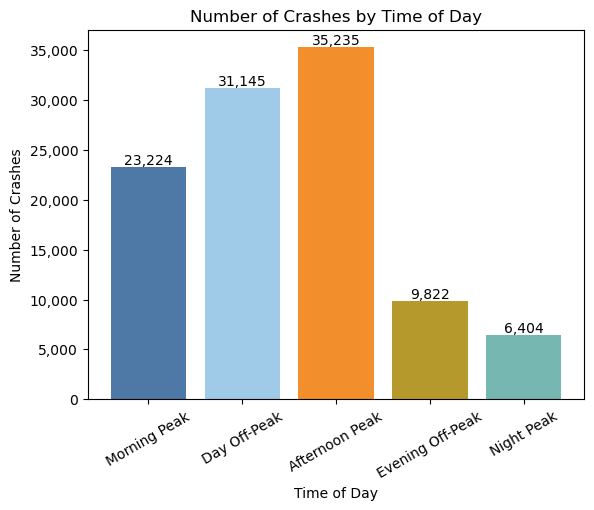

In [45]:
time_counts = time_counts_df.set_index('time_of_day')['crash_count']

order = ['Morning Peak', 'Day Off-Peak', 'Afternoon Peak', 'Evening Off-Peak', 'Night Peak']

time_counts = time_counts.reindex(order)

plt.figure()
bars = plt.bar(
    time_counts.index,
    time_counts.values,
    color=['#4E79A7', '#A0CBE8', '#F28E2B', '#B6992D', '#76B7B2'])

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Number of Crashes by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Crashes')

plt.xticks(rotation=30)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}", 
        ha='center',
        va='bottom'
    )

plt.show()



### 4.2 Group Bar Charts - Crashes Incidents: Weekday vs Weekend
To further investigate the differences in crash incidents between weekdays and weekends, a grouped bar chart was used to separate crash patterns.   
Weekday crashes outnumber weekend crashes across all time periods. This is especially notable during the weekday afternoon peak period where crash numbers (approx. 30,000) are six times higher compared to the same time period on the weekend (approx. 5,000).  This is likely due to the increased traffic volumes during peak commute periods.

A change in the pattern can be seen as weekend crash incidents are more evenly distributed compared to weekday crash incidents, with the weekend crash incidents occurring during day off-peak times (10am - 3pm).  This coincides with the time when social activities tend to occur on the weekend (e.g. shopping trips, recreational activities).  

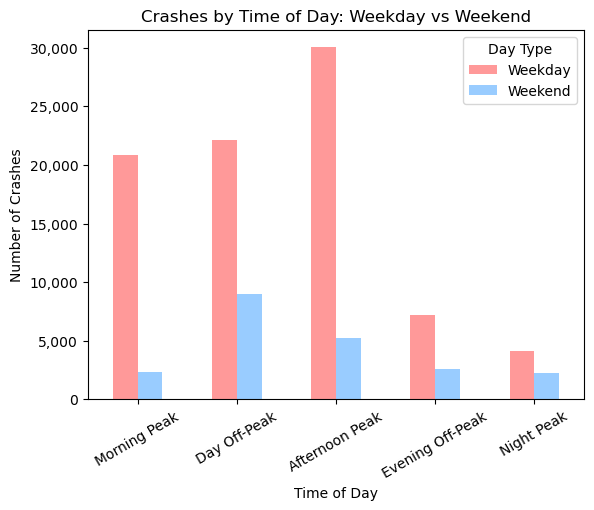

In [46]:
time_day_counts = metro_df.groupby(['time_of_day', 'day_type']).size().unstack()

order = ['Morning Peak', 'Day Off-Peak', 'Afternoon Peak', 'Evening Off-Peak', 'Night Peak']
time_day_counts = time_day_counts.reindex(order)

time_day_counts.plot(
    kind='bar',
    color=['#FF9999', '#99CCFF']  # Weekday (red), Weekend (blue)
)

plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Crashes by Time of Day: Weekday vs Weekend')
plt.xlabel('Time of Day')
plt.ylabel('Number of Crashes')
plt.xticks(rotation=30)
plt.legend(title='Day Type')

plt.show()



### 4.3 Bar Chart - Speed Limit vs Crash Incidents

Using the values from 3.3.3 above, this bar chart analyses the relationship between speed limits and crash incidents.
The 110km/h speed limit category has the highest number of crashes, followed by the 60 km/h and 70 km/h speed limits.  Lower speed limit areas (10 km/h  to 50 km/h) had smaller numbers of crash incidents.
   
It should be noted that the 60 km/h and 70 km/h speed limits are most common speeds within the Perth Metro area, and the combined number of crashes (38,441) from these two speed limit categories are almost equivalent to the number of crashes in the 110 km/h speed limit category which is associated with the outer Perth Metro open roads.     

Overall, there is a higher likelihood of a crash occurring in the Perth Metro at higher speed limits. 

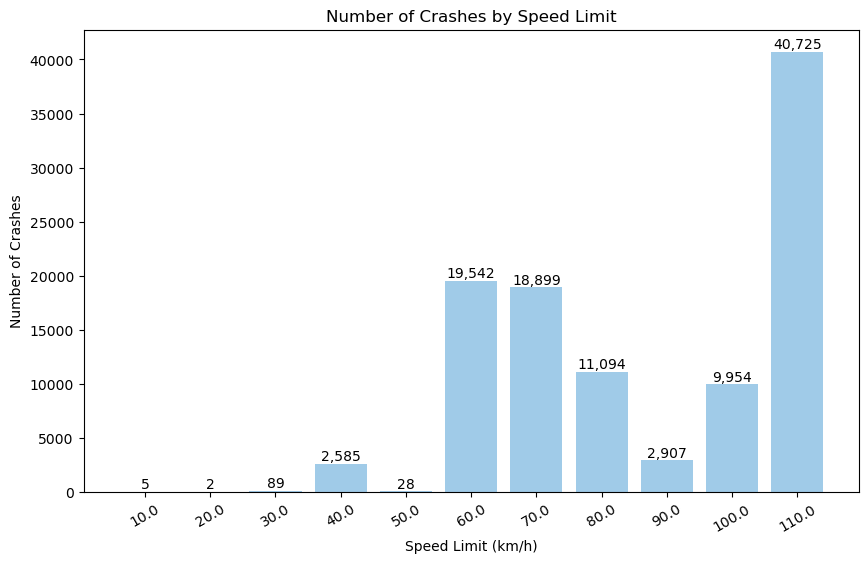

In [47]:
speed_counts = metro_df['max_speed'].value_counts().sort_index()

plt.figure(figsize=(10,6))

bars = plt.bar(
    speed_counts.index.astype(str),
    speed_counts.values,
    color="#A0CBE8"  # soft blue
)

plt.title('Number of Crashes by Speed Limit')
plt.xlabel('Speed Limit (km/h)')
plt.ylabel('Number of Crashes')

plt.xticks(rotation=30)

# Add labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha='center',
        va='bottom'
    )

plt.show()

#### 4.4 Bar Chart - Time of Day and Crash Severity

Two charts were used to visualise crash severity by time of day: a stacked bar chart showing the overall severity distribution, and a bar chart focussing on the crash fatalities across each time period.   

While the overall crash severity distribution remains relatively stable across different times of the day, crash fatalities shows a more noticeable pattern. Fatality rates are higher at night. However, this could also be due to other factors such as reduced visibility, driver fatigue or impaired driving. Overall, fatalities account for less than 1.2% at any given time of day.   

Therefore, time of day is not a strong predictor of overall crash severity, but appears to have some influence on the likelihood of fatalities.

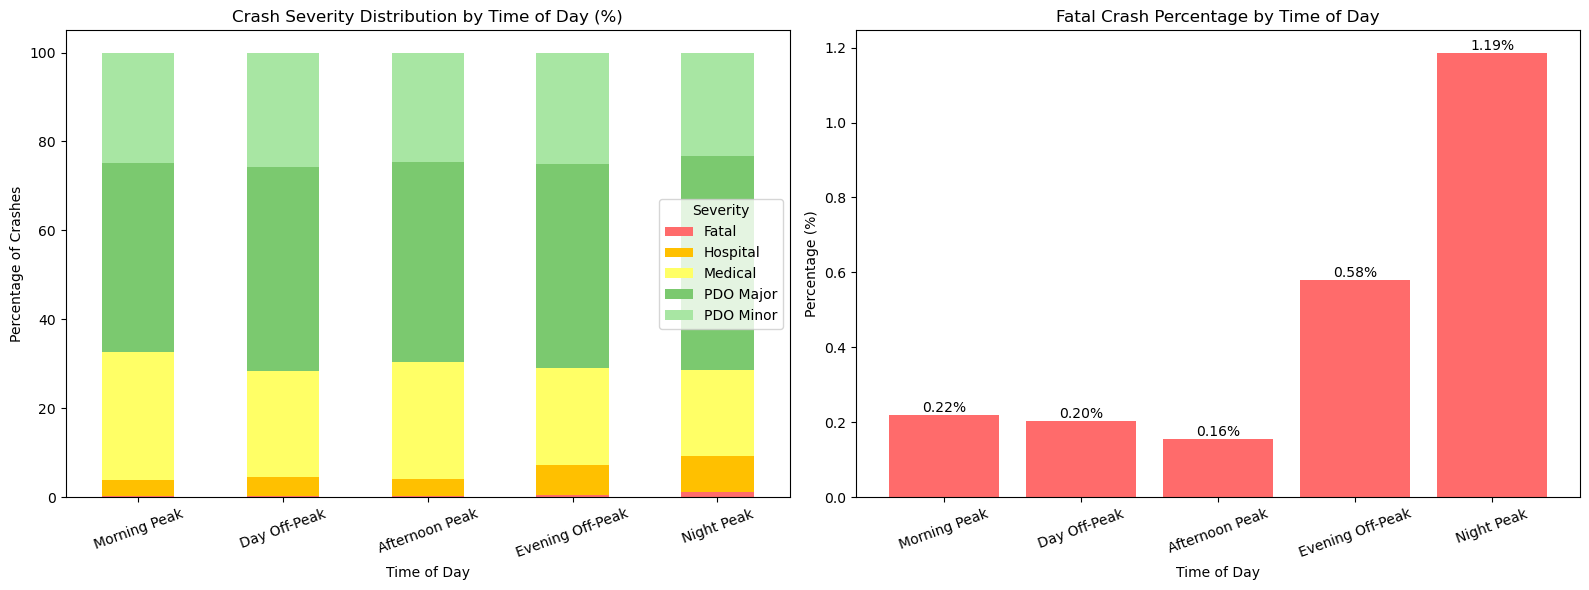

In [48]:

time_severity = pd.crosstab(
    metro_df['time_of_day'], 
    metro_df['SEVERITY'])

time_severity_pct = time_severity.div(
    time_severity.sum(axis=1), axis=0) * 100

fatal_pct = time_severity_pct['Fatal'].reindex(order)

order = ['Morning Peak', 'Day Off-Peak', 'Afternoon Peak', 'Evening Off-Peak', 'Night Peak']
time_severity_pct = time_severity_pct.reindex(order)

color_map = {
    'PDO Minor': '#A8E6A3',
    'PDO Major': '#7BC96F',
    'Medical': '#FFFF66',
    'Hospital': '#FFC000',
    'Fatal': '#FF6B6B'}

colors = [color_map[col] for col in time_severity_pct.columns]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

time_severity_pct.plot(
    kind='bar',
    stacked=True,
    color=colors,
    ax=axes[0])

axes[0].set_title('Crash Severity Distribution by Time of Day (%)')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Percentage of Crashes')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Severity')


bars = axes[1].bar(
    fatal_pct.index,
    fatal_pct.values,
    color='#FF6B6B')

for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}%",
        ha='center',
        va='bottom')

axes[1].set_title('Fatal Crash Percentage by Time of Day')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 4.5 Boxplot - Speed limits and Crash Severity 

A boxplot was used to visualise the relationship between speed limits and crash severity.   

Severity in this case refers to the extent of human harm, with injury-related crashes (e.g. Medical, Hospital, Fatal) classed as more severe that non-injury crashes such as Property Damage Only (PDO minor and PDO major).   

From the boxplot, it can be observed that crashes across all levels of severity tend to be associated with higher speed limits areas, as the median speed limit for each severity category ranges from 80 km/h to 100 km/h. Further, 50% of these crashes tend to occur at speed limits above 70 km/h. 

A pattern could be seen where injury-related crashes become more severe (Medical->Hospital->Fatal) as speed increases, with median speed limits rising from 80 km/h (Medical) to 90 km/h (Hospital) to 100 km/h (Fatal).
It should also be noted that non-injury related crashes, i.e. PDO minor and PDO major show similar speed limit distributions to the injury severity categories but, they extend to lower speed limits. This suggests that crashes with no human harm (i.e. near-misses or lucky escapes) happens at all speed limits.

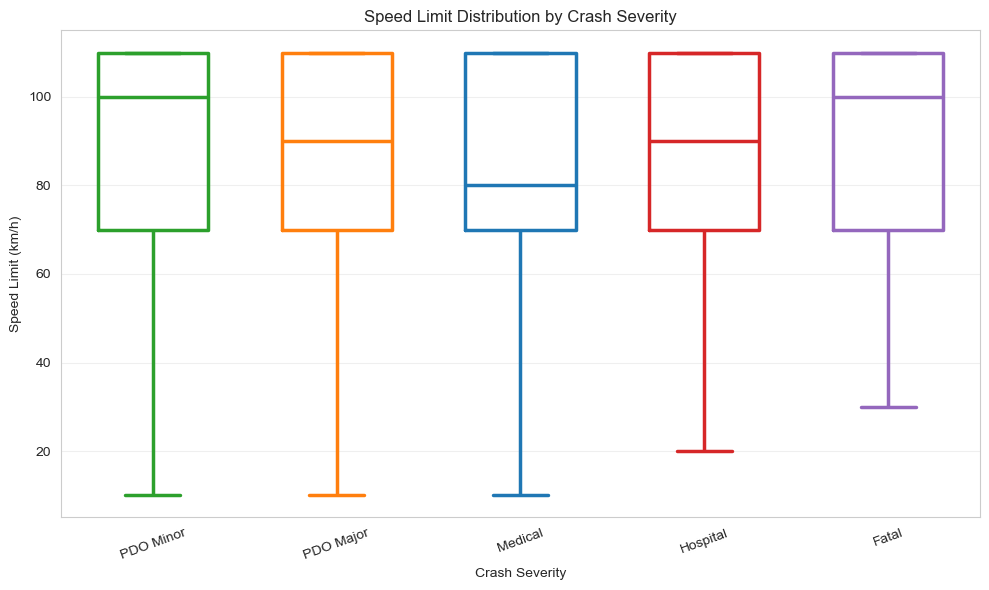

In [57]:
sns.set_style("whitegrid")

custom_palette = ['#F3F30B', '#7BC96F', "#A8E6A3", '#F28E2B', '#E15759']

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    x='SEVERITY',
    y='max_speed',
    data=metro_df,
    order=['PDO Minor', 'PDO Major', 'Medical', 'Hospital', 'Fatal'],
    hue='SEVERITY',
    fill=False,
    palette='tab10',
    linewidth=2.5,
    width=0.6,
    dodge=False,
    legend=False
)

for patch in ax.artists:
    patch.set_alpha(0.6)

ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.grid(axis='x', visible=False)

# Labels
plt.title('Speed Limit Distribution by Crash Severity')
plt.xlabel('Crash Severity')
plt.ylabel('Speed Limit (km/h)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Conclusion

This analysis examined Perth Metropolitan crash data over a 5-year period (2019–2023) to investigate the influence of time of day and speed limits on crash frequency and severity.

The analysis found that time of day does influence the likelihood of a crash occurring. Overall, crash incidents were highest during the Afternoon Peak period (3pm – 6:30pm).  Upon further examination, Weekday crashes dominated in numbers across all time of day periods, with the Afternoon Peak recording approximately six times more crash incidents than the equivalent period for the Weekend period.  This could be associated with the higher traffic volumes during the working week, especially during the Afternoon Peak where the busy work to home commute tends to occur.   The Weekend showed fewer crash incidents with a shift towards more crash incidents occuring during the Day Off-peak period (10am - 3pm), which is consistent with leisure and social travel behaviours (e.g. shopping trips, social and recreational activities).

When examining whether the time of day influences the severity of a crash, no discernable pattern could be seen as severity was evenly distributed accross all times of day.  Although fatal crashes were recorded during the evening periods (Evening Off-peak and Night Peak), fatalities made up a small percentage of all crash incidents and did not affect the overall severity distribution.

Shifting the analysis to investigate the impact of speed limits, the highest number of crash incidents were recorded in the 110 km/h speed limit category, followed by 60 km/h and 70 km/h, which are the most common speed limits on Perth Metropolitan roads (excluding freeways and highways). This reinforces that higher speed limits areas are associated with a greater likelihood of crash incidents. Speed limits were also found to be a factor in the crash severity as injury-related severity increased with speed.  This was evident as the median speed limits increased, the level of severity also increased (e.g. Medical->Hospital->Fatal).

In summary, time of day affects the when crashes happen but shows limited influence on crash severity, whilst speed limits show a stronger relationship with both the frequency of crashes and crash severity.